In [ ]:
!pip install tensorflow scikit-learn pandas

In [2]:
import pandas as pd
from google.colab import drive
import csv

# Mount Google Drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Colab Notebooks/SRSA/dataset.csv"

df = pd.read_csv(file_path, quotechar='"', low_memory=False)

print(df.shape)
df.head()

Mounted at /content/drive
(246945, 378)


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# checking is there any null value and number of unique disease
print(df.isnull().sum().sum())
print(df['diseases'].nunique())

0
773


In [4]:
# split Features and Target
X = df.drop("diseases", axis=1)
y = df["diseases"]

In [ ]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Total classes: ", len(le.classes_))

Total classes:  773


In [ ]:
# one-hot encoding
from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y_encoded)

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model = Sequential([
    Dense(512, activation='relu', input_shape=(X.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),

    Dense(y_cat.shape[1], activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# adding early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.7315 - loss: 1.2566 - val_accuracy: 0.8411 - val_loss: 0.4504
Epoch 2/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8333 - loss: 0.5126 - val_accuracy: 0.8449 - val_loss: 0.4190
Epoch 3/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - accuracy: 0.8413 - loss: 0.4720 - val_accuracy: 0.8481 - val_loss: 0.4020
Epoch 4/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.8456 - loss: 0.4510 - val_accuracy: 0.8481 - val_loss: 0.4027
Epoch 5/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - accuracy: 0.8488 - loss: 0.4371 - val_accuracy: 0.8517 - val_loss: 0.3977
Epoch 6/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.8504 - loss: 0.4275 - val_accuracy: 0.8498 - val_loss: 0.3906
Epoch 7/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.8524 - loss: 0.4185 - val_accuracy: 0.8510 - val_loss: 0.3927
Epoch 8/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8529 -

In [ ]:
# evaluate model
loss, acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", acc)

1544/1544 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8576 - loss: 0.3741
Test Accuracy: 0.857620120048523


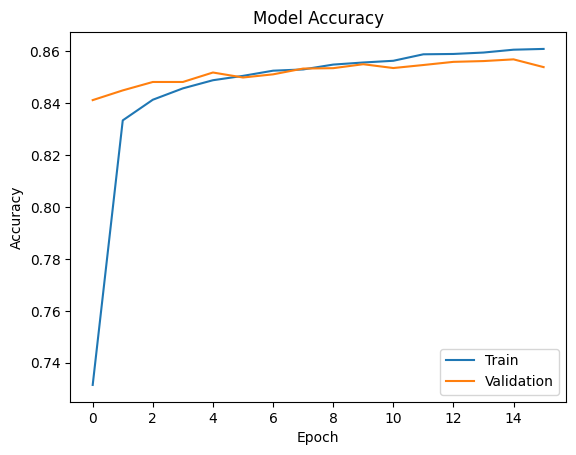

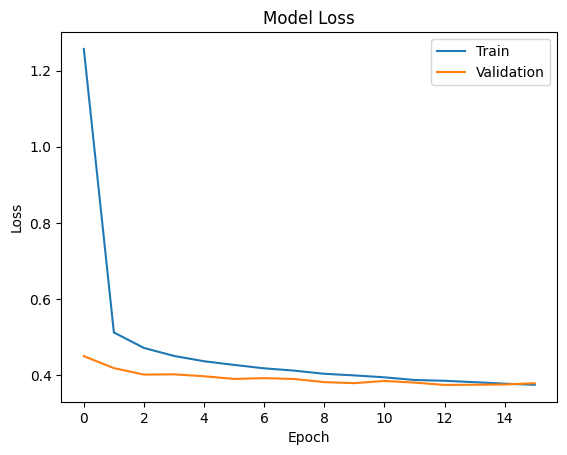

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
import numpy as np

def predict_top3(model, input_vector):
    input_vector = np.array(input_vector).reshape(1, -1)

    preds = model.predict(input_vector)[0]

    top_indices = preds.argsort()[-3:][::-1]

    results = []
    for i in top_indices:
        disease = le.inverse_transform([i])[0]
        confidence = preds[i]

        results.append((disease, float(confidence)))

    return results

In [ ]:
sample = X_test.iloc[0].values

print(predict_top3(model, sample))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
[('glaucoma', 0.32356542348861694), ('corneal disorder', 0.2998221516609192), ('retinal detachment', 0.11127124726772308)]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/Colab Notebooks/SRSA/Disease_Prediction.h5")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pickle

with open("/content/drive/MyDrive/Colab Notebooks/SRSA/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [5]:
import json

features = list(X.columns)

with open("/content/drive/MyDrive/Colab Notebooks/SRSA/features.json", "w") as f:
  json.dump(features, f);